In [1]:
import os

# uncomment to disable NVIDIA GPUs
#os.environ['CUDA_VISIBLE_DEVICES'] = ''
# or pick the device (cpu, gpu, and tpu)
#os.environ['JAX_PLATFORMS'] = 'cpu'

# change JAX GPU memory preallocation fraction
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '.95'

# you do not want this
#os.environ['XLA_FLAGS'] = '--xla_gpu_deterministic_ops=true'

import jax
#jax.print_environment_info()

!nvidia-smi --query-gpu=gpu_name --format=csv,noheader

NVIDIA GeForce GTX 1060 6GB


In [2]:
import matplotlib.pyplot as plt
import matplotlib_inline


matplotlib_inline.backend_inline.set_matplotlib_formats('jpeg')

from pmwd import (
    Configuration,
    Cosmology, SimpleLCDM,
    boltzmann, linear_power, growth,
    white_noise, linear_modes,
    lpt,
    nbody,
    scatter,
)
from pmwd.pm_util import fftinv
from pmwd.spec_util import powspec
from pmwd.vis_util import simshow

In [3]:
if jax.default_backend() == 'gpu':
    ptcl_spacing = 1.  # Lagrangian space Cartesian particle grid spacing, in Mpc/h by default
    ptcl_grid_shape = (128,) * 3
else:
    ptcl_spacing = 4.
    ptcl_grid_shape = (64,) * 3

conf = Configuration(ptcl_spacing, ptcl_grid_shape, mesh_shape=2)  # 2x mesh shape

print(conf)  # with other default parameters
print(f'\n Simulating {conf.ptcl_num} particles with a {conf.mesh_shape} mesh for {conf.a_nbody_num} time steps.')

Configuration(ptcl_spacing=1.0,
              ptcl_grid_shape=(128, 128, 128),
              mesh_shape=(256, 256, 256),
              cosmo_dtype=dtype('float64'),
              pmid_dtype=dtype('int16'),
              float_dtype=dtype('float32'),
              k_pivot_Mpc=0.05,
              T_cmb=2.7255,
              M=1.98847e+40,
              L=3.0856775815e+22,
              T=3.0856775815e+17,
              transfer_fit=True,
              transfer_fit_nowiggle=False,
              transfer_lgk_min=-4,
              transfer_lgk_max=3,
              transfer_lgk_maxstep=0.0078125,
              growth_rtol=1.4901161193847656e-08,
              growth_atol=1.4901161193847656e-08,
              growth_inistep=(1, None),
              lpt_order=2,
              a_start=0.015625,
              a_stop=1,
              a_lpt_maxstep=0.0078125,
              a_nbody_maxstep=0.015625,
              symp_splits=((0, 0.5), (1, 0.5)),
              chunk_size=16777216)

 Simulating 2097

In [4]:
#cosmo = Cosmology(conf, A_s_1e9=2.0, n_s=0.96, Omega_m=0.22, Omega_b=0.05, h=0.7, xi_=None )
# or simply use the predefined SimpleLCDM
cosmo = SimpleLCDM(conf)

print(cosmo)

Cosmology(A_s_1e9=Array(2., dtype=float64),
          n_s=Array(0.96, dtype=float64),
          Omega_m=Array(0.3, dtype=float64),
          Omega_b=Array(0.05, dtype=float64),
          h=Array(0.7, dtype=float64),
          xi_=None,
          omega_R0=Array(8.99e-05, dtype=float64),
          Omega_k_=None,
          w_0_=None,
          w_a_=None,
          transfer=None,
          growth=None,
          varlin=None)


In [5]:
%time cosmo = jax.block_until_ready(boltzmann(cosmo, conf))
%timeit jax.block_until_ready(boltzmann(cosmo, conf))

CPU times: user 2.1 s, sys: 121 ms, total: 2.22 s
Wall time: 2.53 s
15.2 ms ± 375 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [6]:
seed = 0
modes = white_noise(seed, conf)

modes = linear_modes(modes, cosmo, conf)

In [7]:
%time ptcl, obsvbl = jax.block_until_ready(lpt(modes, cosmo, conf))
%timeit jax.block_until_ready(lpt(modes, cosmo, conf)) 
ptcl.disp.std(), ptcl.vel.std()

CPU times: user 714 ms, sys: 33.3 ms, total: 747 ms
Wall time: 757 ms
17.7 ms ± 110 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


(Array(0.091, dtype=float32), Array(0.006, dtype=float32))

In [8]:
#%time jax.block_until_ready(nbody(ptcl, obsvbl, cosmo, conf))
#%time ptcl, obsvbl = jax.block_until_ready(nbody(ptcl, obsvbl, cosmo, conf))
#ptcl.disp.std(), ptcl.vel.std()
print('se nao chama a func nbody, o epectro fica congelado nas condicoes iniciais')

se nao chama a func nbody, o epectro fica congelado nas condicoes iniciais


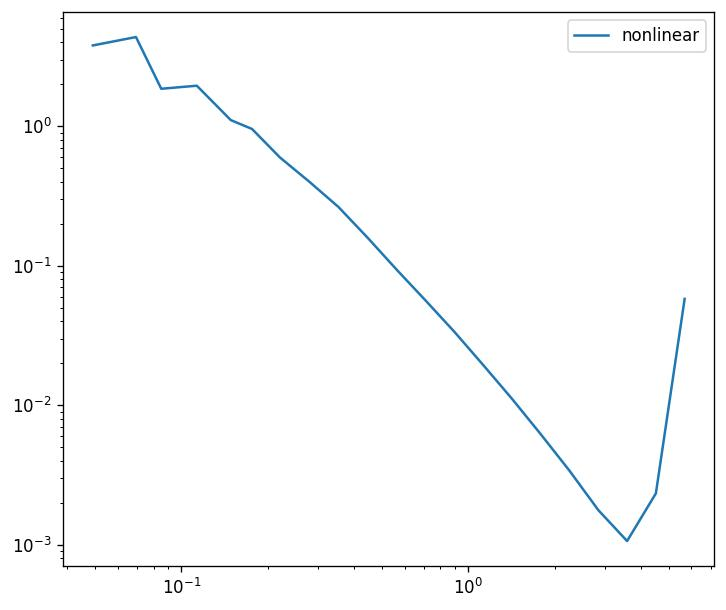

In [9]:
dens = scatter(ptcl, conf)

k, P, _, _ = powspec(dens, conf.cell_size)

plt.figure(figsize=(7, 6), dpi=120)
plt.loglog(k, P, ls='-', label='nonlinear')
plt.legend();

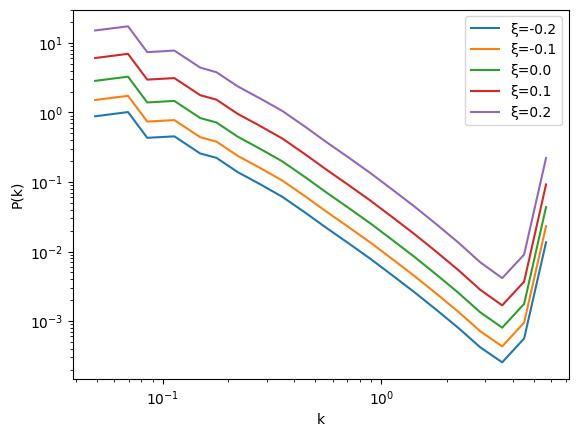

In [10]:
def nolin_ps(cosmo, modes):
    cosmo = jax.block_until_ready(boltzmann(cosmo, conf))
    modes = linear_modes(modes, cosmo, conf)
    ptcl, _ = jax.block_until_ready(lpt(modes, cosmo, conf))
    dens = scatter(ptcl, conf)
    return powspec(dens, conf.cell_size)[:2]

cosmology = Cosmology(conf, A_s_1e9=2.0, n_s=0.96, Omega_m=0.3, Omega_b=0.05, h=0.7, xi_= 0.0, w_0_ =-1.0)
modes = white_noise(0, conf)

xis = [-0.2, -0.1, 0.0, +0.1, +0.2]
fig, ax = plt.subplots()
for xi in xis:
    cosmo = cosmology.replace(xi_=xi)
    k, P   = nolin_ps(cosmo, modes)
    ax.loglog(k, P, label=f'ξ={xi}')
ax.set(xlabel='k', ylabel='P(k)')
ax.legend()
plt.show()